In [50]:
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window
import matplotlib.pyplot as plt
import numpy as np
import os
from samgeo import SamGeo
from samgeo import SamGeo2
import torch

In [71]:
fp = '../data/raw/orthomosaics/2025-04-29_norte-1_orthomosaic.tif'

# config de ventana de recorte
col_off, row_off = 3200, 2000   # offset desde esq sup izq (X, Y)
width, height = 1200, 1200      # tamaño del cuadro a extraer
window = Window(col_off, row_off, width, height)

In [58]:
# funcion para estirar valores para viz
def get_clean_stretch(band, mask, p_low=2, p_high=98):
    valid_pixels = band[mask]

    if valid_pixels.size == 0:
        return np.zeros_like(band)
    
    low, high = np.percentile(valid_pixels, (p_low, p_high))

    stretched = np.clip(band, low, high)

    if high - low == 0:
        return np.zeros_like(band)
        
    return (stretched - low) / (high - low)

Carga y visualizacion de imagen

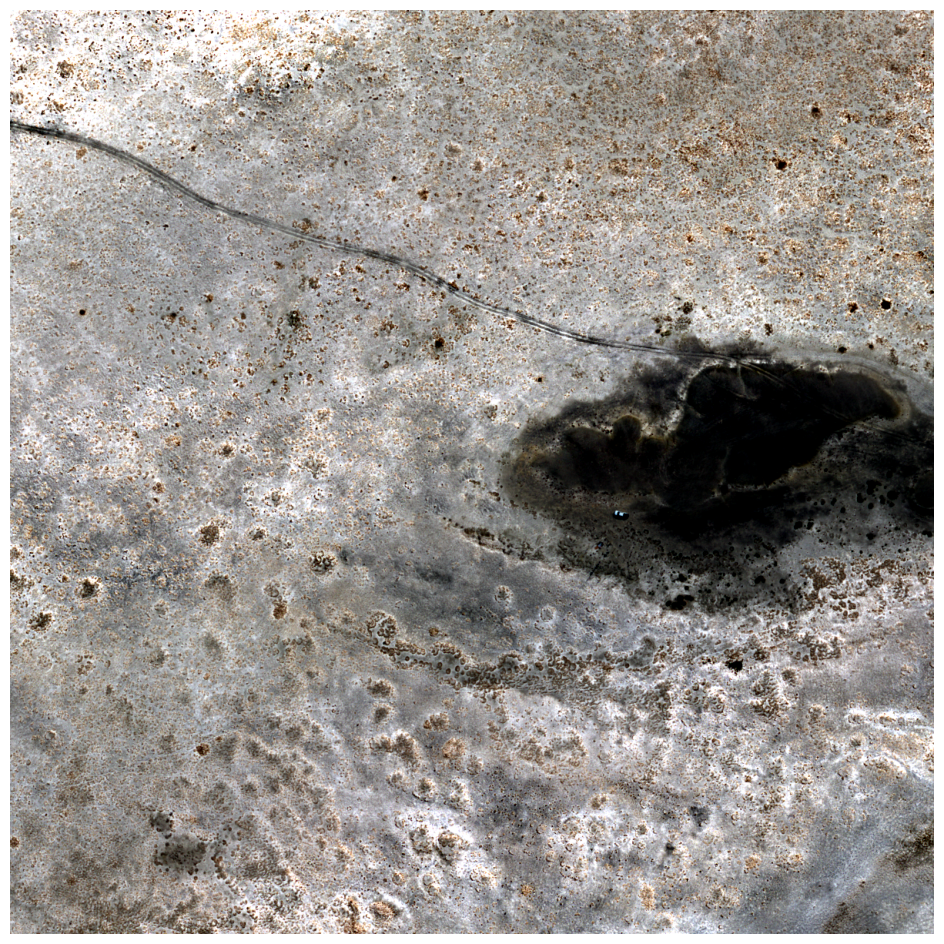

In [ ]:
# abrir archivo y recortar a una ventana
with rasterio.open(fp) as src:

    # seleccion de bandas utiles (omite pancromatica)
    bands = [1, 2, 3, 4, 5]
    num_bands = len(bands)

    # lectura de bandas especificadas y clipeo a ventana
    subset = src.read(bands, window=window).astype('float32')

    # manejo de nodata
    if src.nodata is not None:
        mask = ~np.all(subset == src.nodata, axis=0)
    else:
        mask = ~np.all(subset == 0, axis=0)

    # metadatos del recorte
    subset_meta = src.meta.copy()
    subset_meta.update({
        'height': window.height,
        'width': window.width,
        'transform': src.window_transform(window),
        'count': len(bands)
    })

# aplicar estiramiento
list_stretched = []
for i in range(num_bands):
    band_st = get_clean_stretch(subset[i], mask)
    list_stretched.append(band_st)

# componer imagen
rgb = np.dstack((list_stretched[2], list_stretched[1], list_stretched[0]))
rgb[~mask] = 1  # Los píxeles fuera de la máscara se verán blancos

# viz
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.axis('off')
plt.show()

Preparacion de imagen para SAM

In [62]:
temp_sam_input = "subset_rgb_for_sam.tif"
sam_meta = subset_meta.copy()
sam_meta.update({
    'count': 3,
    'dtype': 'uint8',
    'nodata': 0
})

# Escalar a 8-bits
red_8bit = (list_stretched[2] * 255).astype('uint8')
green_8bit = (list_stretched[1] * 255).astype('uint8')
blue_8bit = (list_stretched[0] * 255).astype('uint8')

# Forzar el NoData a 0 para que SAM no segmente el fondo
red_8bit[~mask] = 0
green_8bit[~mask] = 0
blue_8bit[~mask] = 0

with rasterio.open(temp_sam_input, 'w', **sam_meta) as dst:
    dst.write(red_8bit, 1)
    dst.write(green_8bit, 2)
    dst.write(blue_8bit, 3)

SAMGEO1

In [ ]:
# # definicion de parametros de segmentacion
# sam_parameters = {
#     'points_per_side': 512,
#     'pred_iou_thresh': 0.8,
#     'stability_score_thresh': 0.8,
#     'min_mask_region_area': 2
# }

# # seleccion del modelo
# sam = SamGeo(
#     model_type='vit_h',
#     sam_kwargs=sam_parameters
# )

# # ejecucion del modelo y generacion de mascaras
# sam.generate(
#     temp_sam_input, 
#     erosion_kernel=None, 
#     foreground=False, 
#     strip=True,
#     )

# # guardado de resultados
# sam.save_masks(output="sam1_masks.tif")
# sam.raster_to_vector("sam1_masks.tif", "sam1_masks.gpkg")

[ WARN:0@48922.242] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@48922.242] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@48922.243] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@48922.243] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@48922.243] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42113 (0xa481) encountered


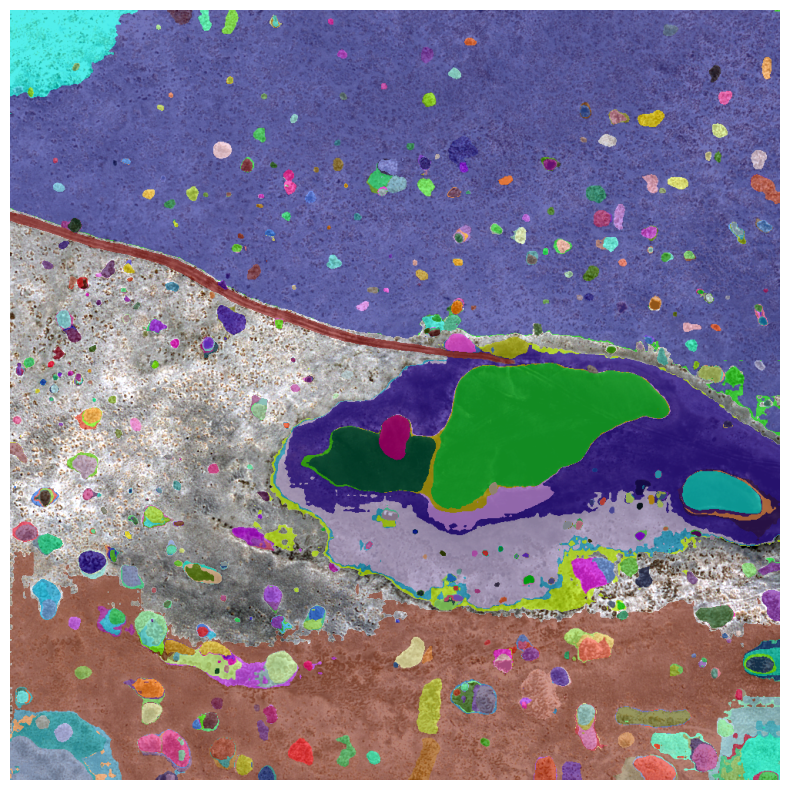

In [81]:
sam.show_anns(axis="off", alpha=0.7)

SAMGEO2

In [ ]:
# # seleccion del modelo y definicion de parametros de segmentacion
# sam2 = SamGeo2(
#     model_id="sam2-hiera-large",
#     apply_postprocessing=False,
#     points_per_side=256,
#     points_per_batch=64,
#     pred_iou_thresh=0.7,
#     stability_score_thresh=0.8,
#     stability_score_offset=0.7,
#     crop_n_layers=1,
#     box_nms_thresh=0.7,
#     crop_n_points_downscale_factor=2,
#     min_mask_region_area=2,
#     use_m2m=True,
# )

# # ejecucion del modelo y generacion de mascaras
# sam2.generate(
#     temp_sam_input,
#     erosion_kernel=None, 
#     foreground=False, 
#     strip=True
#     )

# # guardado de resultados
# sam2.save_masks(output="sam2_masks.tif")
# sam2.raster_to_vector("sam2_masks.tif", "sam2_masks.gpkg")

[ WARN:0@34857.077] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@34857.077] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@34857.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@34857.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@34857.078] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42113 (0xa481) encountered


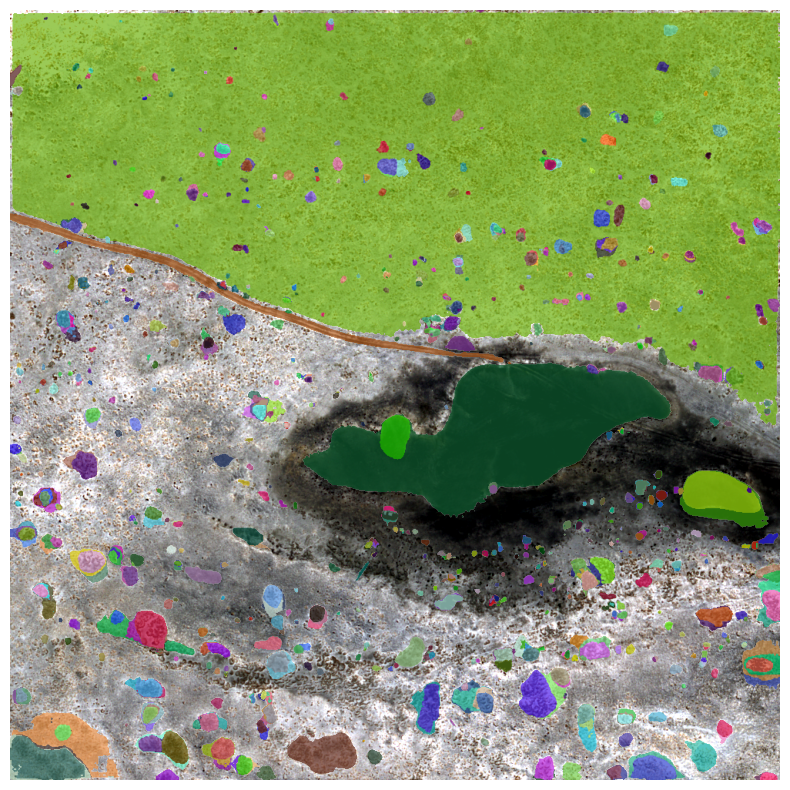

In [78]:
sam2.show_anns(axis="off", alpha=0.7)